# Hw1 :  Fairness & Bias in AI
# **Name : Omkumar M. Patel <br>**
# **Student ID: 222110936 <br>**

### Libraries & Dependencies


In [96]:
#run this once, start of each session.
# !pip install ucimlrepo

In [121]:
# import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import torch.optim as optim
import os
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
import itertools

### Understanding the Dataset

In [98]:
# fetch dataset
adult = fetch_ucirepo(id=2)

# data (as pandas dataframes)
X = adult.data.features
y = adult.data.targets

In [99]:
adult.variables

,name,role,type,demographic,description,units,missing_values
0,age,Feature,Integer,Age,N/A,None,no
1,workclass,Feature,Categorical,Income,"Private, Self-emp-not-inc, Self-emp-inc, Feder...",None,yes
2,fnlwgt,Feature,Integer,None,None,None,no
3,education,Feature,Categorical,Education Level,"Bachelors, Some-college, 11th, HS-grad, Prof-...",None,no
4,education-num,Feature,Integer,Education Level,None,None,no
5,marital-status,Feature,Categorical,Other,"Married-civ-spouse, Divorced, Never-married, S...",None,no
6,occupation,Feature,Categorical,Other,"Tech-support, Craft-repair, Other-service, Sal...",None,yes
7,relationship,Feature,Categorical,Other,"Wife, Own-child, Husband, Not-in-family, Other...",None,no
8,race,Feature,Categorical,Race,"White, Asian-Pac-Islander, Amer-Indian-Eskimo,...",None,no
9,sex,Feature,Binary,Sex,"Female, Male.",None,no


In [100]:
adult.metadata

{'uci_id': 2,
 'name': 'Adult',
 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult',
 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv',
 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ',
 'area': 'Social Science',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 48842,
 'num_features': 14,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'],
 'target_col': ['income'],
 'index_col': None,
 'has_missing_values': 'yes',
 'missing_values_symbol': 'NaN',
 'year_of_dataset_creation': 1996,
 'last_updated': 'Tue Sep 24 2024',
 'dataset_doi': '10.24432/C5XW20',
 'creators': ['Barry Becker', 'Ronny Kohavi'],
 'intro_paper': None,
 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was ex

In [101]:
df1 = pd.DataFrame(y)
df = pd.DataFrame(X)
df = pd.concat([df, df1], axis=1)
df.head(10)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


### Visualizations

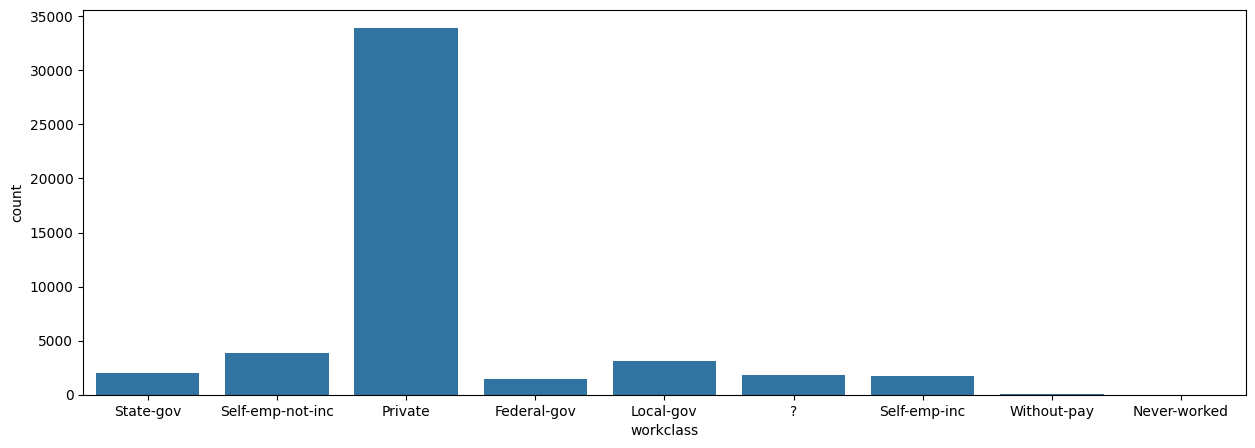

In [102]:
plt.figure(figsize=(15,5))
sns.countplot(x='workclass', data=df)
plt.show()

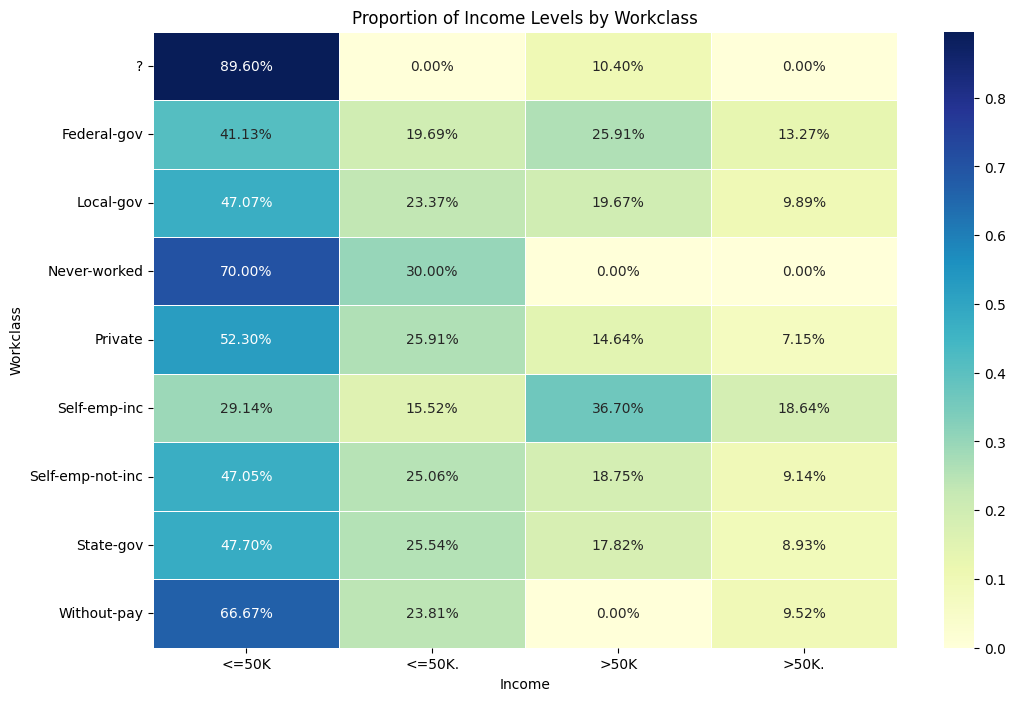

In [103]:
#contingency table of workclass and income
crosstab_df = pd.crosstab(df['workclass'], df['income'], normalize='index')

plt.figure(figsize=(12, 8))
sns.heatmap(crosstab_df, annot=True, fmt=".2%", cmap="YlGnBu", linewidths=.5)
plt.title('Proportion of Income Levels by Workclass')
plt.xlabel('Income')
plt.ylabel('Workclass')
plt.show()

In [104]:
df['income'].value_counts()

,count
income,
<=50K,24720
<=50K.,12435
>50K,7841
>50K.,3846


### Fixing Typo and Assigning Binary Labels.


In [105]:
df['income'] = df['income'].replace({'<=50K.': 0, '<=50K':0, '>50K.': 1, '>50K':1 })
df['income'].value_counts()

/tmp/ipython-input-1855584782.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['income'] = df['income'].replace({'<=50K.': 0, '<=50K':0, '>50K.': 1, '>50K':1 })


,count
income,
0,37155
1,11687


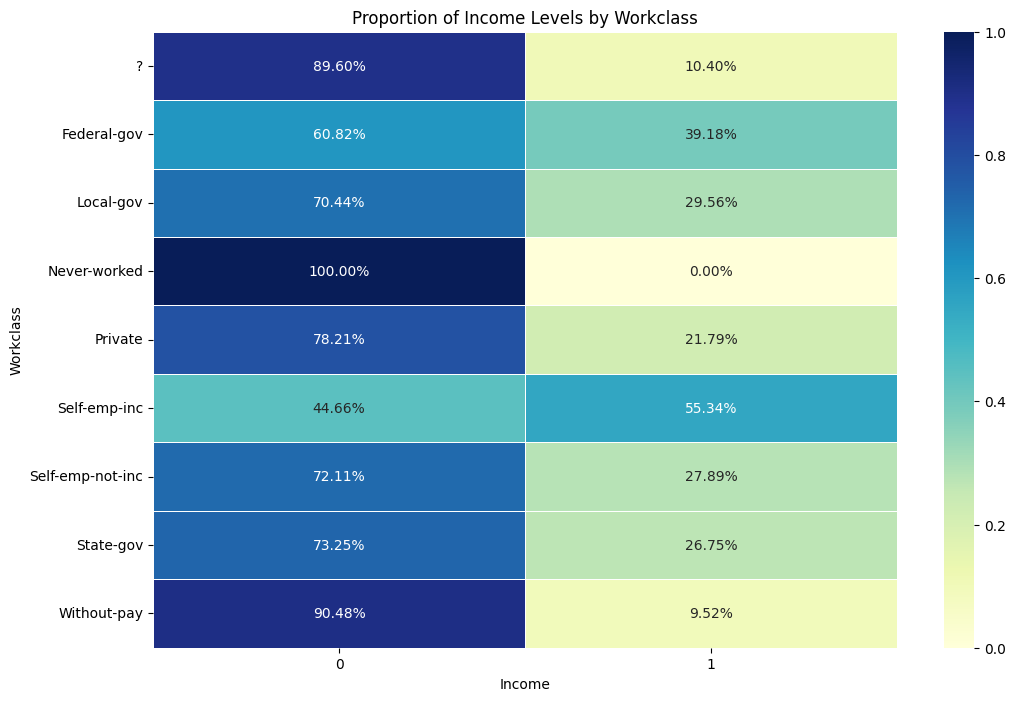

In [106]:
#contingency table of workclass and income
crosstab_df = pd.crosstab(df['workclass'], df['income'], normalize='index')

plt.figure(figsize=(12, 8))
sns.heatmap(crosstab_df, annot=True, fmt=".2%", cmap="YlGnBu", linewidths=.5)
plt.title('Proportion of Income Levels by Workclass')
plt.xlabel('Income')
plt.ylabel('Workclass')
plt.show()

### Preprocessing

In [107]:
# dropping null values
df = df.dropna()
X = df.drop('income', axis=1)
y = df['income'].astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [108]:
sex_test = (X_test["sex"].astype(str).str.strip() == "Male").astype(int).values
race_test = X_test["race"].astype(str).str.strip().values

cat_col = X_train.select_dtypes(include=['object', 'category']).columns
print(cat_col)

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country'],
      dtype='object')


In [109]:
#Chaning Categorical Features to numerical
le = LabelEncoder()

encoders = {}
for col in cat_col:

    train_vals = X_train[col].astype(str).values
    # add UNK to prevent crashes if test contains unseen category
    le.fit(np.concatenate([train_vals, np.array(["UNK"], dtype=object)]))
    encoders[col] = le

    X_train[col] = le.transform(train_vals)

    test_vals = X_test[col].astype(str).values
    known = np.isin(test_vals, le.classes_)
    test_safe = np.where(known, test_vals, "UNK")
    X_test[col] = le.transform(test_safe)


In [110]:
# Normalizing the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.values.astype(np.float32)).astype(np.float32)
X_test_scaled  = scaler.transform(X_test.values.astype(np.float32)).astype(np.float32)

y_train_scaled = y_train.values.astype(np.float32).reshape(-1, 1)
y_test_scaled  = y_test.values.astype(np.float32).reshape(-1, 1)

print("X_train:", X_train_scaled.shape, "y_train:", y_train_scaled.shape,"\n","X_test :", X_test_scaled.shape,  "y_test :", y_test_scaled.shape)
print("sex_test:", sex_test.shape, "race_test:", race_test.shape)
print("Categorical col enc:", cat_col)

X_train: (38096, 14) y_train: (38096, 1) 
 X_test : (9525, 14) y_test : (9525, 1)
sex_test: (9525,) race_test: (9525,)
Categorical col enc: Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country'],
      dtype='object')


In [111]:
# print(X_train_scaled)
print(X_train.head())

       age  workclass  fnlwgt  education  education-num  marital-status  \
22858   37          2   48976          9             13               4   
47248   23          4  181796         11              9               2   
11979   34          4   69251         11              9               2   
23082   38          6  184456         11              9               2   
1102    39          5  218184          6              5               2   

       occupation  relationship  race  sex  capital-gain  capital-loss  \
22858          10             1     5    0          4865             0   
47248          12             0     5    1             0             0   
11979          14             0     1    1             0             0   
23082           8             0     5    1          3464             0   
1102            4             0     5    1             0          1651   

       hours-per-week  native-country  
22858              45              40  
47248              50   

### Training

In [113]:
def make_loader(X_np, y_np, batch_size=32, shuffle=False):
    X_t = torch.tensor(X_np, dtype=torch.float32)
    y_t = torch.tensor(y_np, dtype=torch.float32)
    ds = TensorDataset(X_t, y_t)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train_scaled, y_train_scaled, batch_size=32, shuffle=True)
test_loader  = make_loader(X_test_scaled,  y_test_scaled,  batch_size=1024, shuffle=False)

class MLP(nn.Module):
    # 2 hidden layers (64 each), ReLU; output 1 neuron with Sigmoid
    def __init__(self, input_dim: int):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.sigmoid(self.fc3(x))
        return x

input_size = X_train_scaled.shape[1]
model = MLP(input_size)
print(model)

def probs_to_pred(probs, threshold=0.5):
    return (probs > threshold).astype(int)

@torch.no_grad()
def predict_proba_full(model, X_np):
    model.eval()
    X = torch.tensor(X_np, dtype=torch.float32)
    probs = model(X).detach().cpu().numpy().reshape(-1)
    return probs

def confusion_counts(y_true, y_pred):
    y_true = y_true.astype(int)
    y_pred = y_pred.astype(int)
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    return tp, fn, fp, tn

def tpr(y_true, y_pred):
    tp, fn, _, _ = confusion_counts(y_true, y_pred)
    denom = tp + fn
    return float(tp / denom) if denom > 0 else float("nan")

def fpr(y_true, y_pred):
    _, _, fp, tn = confusion_counts(y_true, y_pred)
    denom = fp + tn
    return float(fp / denom) if denom > 0 else float("nan")

def acc(y_true, y_pred):
  accuracy = float(np.mean(y_true.astype(int) == y_pred.astype(int)))
  return accuracy

def equal_opportunity_gap(y_true, y_pred, sex_binary):
    male = (sex_binary == 1)
    female = (sex_binary == 0)
    tpr_m = tpr(y_true[male], y_pred[male])
    tpr_f = tpr(y_true[female], y_pred[female])
    gap = abs(tpr_m - tpr_f)
    return gap, tpr_m, tpr_f

MLP(
  (fc1): Linear(in_features=14, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)


In [114]:
model = MLP(input_dim=X_train_scaled.shape[1])
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
criterion = nn.BCELoss()
threshold_default = 0.5

history = {
    "epoch": [],
    "test_acc": [],
    "tpr_male": [],
    "tpr_female": [],
    "gap_eqopp": []
}

y_test_flat = y_test_scaled.reshape(-1).astype(int)

for epoch in range(1, 51):
    model.train()
    total_loss = 0.0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)

    probs = predict_proba_full(model, X_test_scaled)
    yhat = probs_to_pred(probs, threshold = threshold_default)

    gap, tpr_m, tpr_f = equal_opportunity_gap(y_test_flat, yhat, sex_test)
    test_a = acc(y_test_flat, yhat)

    history["epoch"].append(epoch)
    history["test_acc"].append(test_a)
    history["tpr_male"].append(tpr_m)
    history["tpr_female"].append(tpr_f)
    history["gap_eqopp"].append(gap)

    if epoch in [1, 20, 50]:
        avg_loss = total_loss / len(train_loader.dataset)
        print(f"epoch {epoch} | train_loss={avg_loss:.4f} | test_acc={test_a:.4f} | "
              f"tpr_m={tpr_m:.4f} | tpr_f={tpr_f:.4f} | gap={gap:.4f}")

print("\n final/last test accuracy : epoch 50 = ", round(history["test_acc"][-1], 5))

epoch 1 | train_loss=0.4738 | test_acc=0.8180 | tpr_m=0.4680 | tpr_f=0.0676 | gap=0.4004
epoch 20 | train_loss=0.3206 | test_acc=0.8442 | tpr_m=0.6426 | tpr_f=0.4958 | gap=0.1468
epoch 50 | train_loss=0.3135 | test_acc=0.8485 | tpr_m=0.5863 | tpr_f=0.4845 | gap=0.1018

 final/last test accuracy : epoch 50 =  0.8485


### Part 1:

In [116]:
from torch._prims_common import check_all_strides
# Standard dev in eqop gap.
std_gap = float(np.std(history["gap_eqopp"], ddof=0))
print(std_gap)
# T/F
check = (abs(history["gap_eqopp"][49]) < 0.04)
print(check)

0.07203843512744694
False


In [117]:
#dummy classifier
majority_class = int(np.mean(y_train_scaled) >= 0.5)  # majority in TRAIN
pred_d = np.full_like(y_test_flat, fill_value=majority_class) #predicting label for every class
gap_d, tpr_m_d, tpr_f_d = equal_opportunity_gap(y_test_flat, pred_d, sex_test)
acc_d = acc(y_test_flat, pred_d)
print(majority_class)
print(f"Dummy accuracy: {acc_d:.4f}")
print(f"Dummy tpr for male: {tpr_m_d:.4f}")
print(f"Dummy tpr for femal: {tpr_f_d:.4f}")
print(f"Dummy gap in equal oppo: {gap_d:.4f}")

0
Dummy accuracy: 0.7577
Dummy tpr for male: 0.0000
Dummy tpr for femal: 0.0000
Dummy gap in equal oppo: 0.0000


#### Final Answers

Q1) Gap in the equal opportunity in the 1st epoch.
<br>
A1) 0.2967
<br><br>

Q2) Gap in the equal opportunity in the 20th epoch.
<br>
A2) 0.1648
<br><br>

Q3) Gap in the equal opportunity in the final epoch.
<br>
A3) 0.1141
<br><br>

Q4) Standard deviation of the gap in the equal opportunities from epoch 1 to 50.
<br>
A4) 0.7880
<br><br>

Q5)True/False: This classifier satisfies equal opportunity with the maximum error of 0.04 (i.e., |TPRmale - TPRfemale|<0.04 , where TPR is True Positive Rate).
<br>
A5) False
<br><br>

Q6) If a classifier achieves equal TPR across groups, does it necessarily achieve equal False Positive Rate (FPR)? (Yes/No)? Why ?
<br>
A6) No. I don't think so, even if the the TPR is equal among groups it's because Y=1 (might have equal no. of tp) condition allows it, while the FPR depends on Y=0, which is why the tn is independent of the tp and they may or may not be equal for different distributions.
<br><br>

Q7) Train a dummy classifier that always predicts the majority class for all the inputs.What is the gap in equal opportunity for this classifier? Why ?
<br>
A7) The gap is zero, the dummy classifier favours the imbalance and always predicts zero, therefore leading to tpr of both male and female to be zero.
<br><br>


In [118]:
thresholds = np.arange(0.2, 1.1, 0.2)
final_probs = predict_proba_full(model, X_test_scaled)
metrics = []

for t in thresholds:
    yhat = (final_probs > t).astype(int)
    gap, tpr_m, tpr_f = equal_opportunity_gap(y_test_flat, yhat, sex_test)
    acc_val = acc(y_test_flat, yhat)        #
    metrics.append({"threshold": t, "gap": gap, "acc": acc_val,
                    "tpr_m": tpr_m, "tpr_f": tpr_f})
    print(f"threshold={t:.1f} | acc={acc_val:.4f} | gap={gap:.4f} | "
          f"tpr_m={tpr_m:.4f} | tpr_f={tpr_f:.4f}")


# Q8- first threshold where tpmr_m < tpr_f
for m in metrics:
  if m["tpr_m"] < m["tpr_f"]:
    print("Threshold where TPR of male lesser than female: ", m["threshold"])
    break


threshold=0.2 | acc=0.7824 | gap=0.1480 | tpr_m=0.9002 | tpr_f=0.7521
threshold=0.4 | acc=0.8428 | gap=0.1163 | tpr_m=0.6994 | tpr_f=0.5831
threshold=0.6 | acc=0.8444 | gap=0.0770 | tpr_m=0.4854 | tpr_f=0.4085
threshold=0.8 | acc=0.8141 | gap=0.0542 | tpr_m=0.2627 | tpr_f=0.2085
threshold=1.0 | acc=0.7577 | gap=0.0000 | tpr_m=0.0000 | tpr_f=0.0000


#### Final Answer
Q8) At what decision threshold does the TPR for the privileged group (male) cross below
the TPR for the protected group (female)?
 <br>
A8)
At no decision threshold the True positive rate (tpr) for male goes below the female.



In [119]:
best_acc = max(metrics, key=lambda m: m["acc"])
best_gap = min(metrics, key=lambda m: m["gap"])
print(best_acc)
print(best_gap)
check_9 = (best_acc['threshold'] == best_gap['threshold'])
print(check_9)

{'threshold': np.float64(0.6000000000000001), 'gap': 0.07695636182687521, 'acc': 0.8444094488188977, 'tpr_m': 0.48540706605222733, 'tpr_f': 0.4084507042253521}
{'threshold': np.float64(1.0), 'gap': 0.0, 'acc': 0.7576902887139108, 'tpr_m': 0.0, 'tpr_f': 0.0}
False


#### Final Answer

Q9)Does maximizing the accuracy correspond to the threshold with the lowest gap in
the Equal Opportunity? (Yes/No) Why?
<br>
A)No, both occur at different thresholds. I think that is because higher accuracy is achieved at higher threshold while lowest gap in equal opportunity occurs at lower threshold.  This is becasue the class imabalance favors easier/conservative predictions (0 in our case).

Final Answer: Q10 and Q11




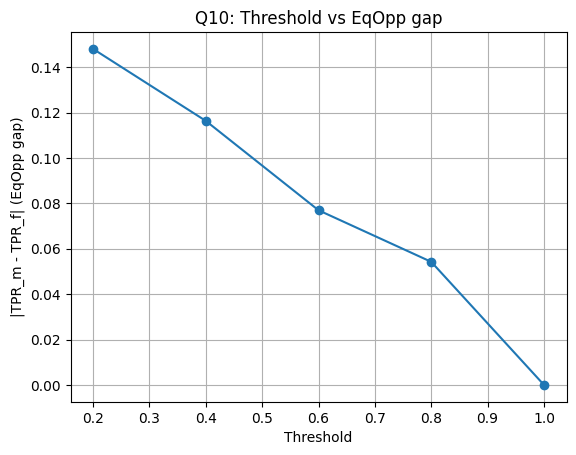

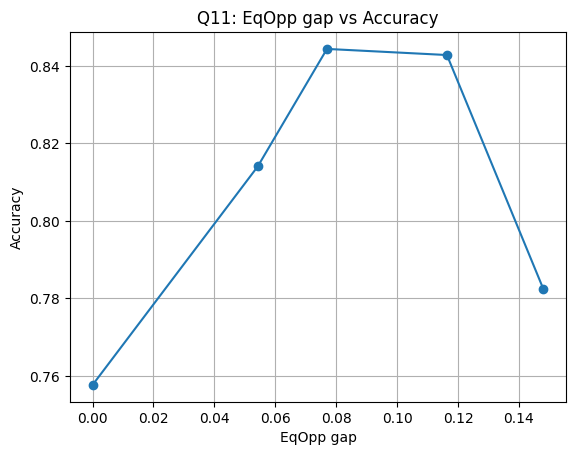

In [144]:
print("Final Answer: Q10 and Q11\n\n")
# Q10: Threshold vs gap
plt.figure()
plt.plot([m["threshold"] for m in metrics], [m["gap"] for m in metrics], marker="o")
plt.xlabel("Threshold"); plt.ylabel("|TPR_m - TPR_f| (EqOpp gap)")
plt.title("Q10: Threshold vs EqOpp gap")
plt.grid(True)

# Q11: Gap vs accuracy
plt.figure()
plt.plot([m["gap"] for m in metrics], [m["acc"] for m in metrics], marker="o")
plt.xlabel("EqOpp gap"); plt.ylabel("Accuracy")
plt.title("Q11: EqOpp gap vs Accuracy")
plt.grid(True)
plt.show()

### Part2:

In [142]:
threshold2 = 0.5
yhat_05 = probs_to_pred(final_probs, threshold=threshold2)
groups = {
    "A_white_male":   (race_test == "White") & (sex_test == 1), #White male
    "B_white_female": (race_test == "White") & (sex_test == 0), #white female
    "C_black_male":   (race_test == "Black") & (sex_test == 1), #black male
    "D_black_female": (race_test == "Black") & (sex_test == 0), #black fem
}

group_tprs = {}
for n, g in groups.items():
    group_tprs[n] = tpr(y_test_flat[g], yhat_05[g])
    print(f"tpr: {n}: {group_tprs[n]:.4f}")

# Compute Equal opportunity gap among subgroups
subgroups = []
subgroup_names = list(group_tprs.keys())
for n in range(len(subgroup_names)):
  for o in range(n+1, len(subgroup_names)):
    s1, s2 = subgroup_names[n] , subgroup_names[o]
    equal_opportunity_gap2 = abs(group_tprs[s1]-group_tprs[s2])
    subgroups.append((s1,s2, equal_opportunity_gap2))

for s1,s2, equal_opportunity_gap2 in subgroups:
  print(f"{s1} - {s2} eqop_gap:  {equal_opportunity_gap2:.4f}")

max_pair = max(subgroups, key=lambda x: x[2])
min_pair = min(subgroups, key=lambda x: x[2])

print(f"maximum gap pair: {max_pair[0]} - {max_pair[1]} (eqop_gap={max_pair[2]:.4f})")
print(f"minimum gap pair: {min_pair[0]} - {min_pair[1]} (eqop_gap={min_pair[2]:.4f})")


tpr: A_white_male: 0.5862
tpr: B_white_female: 0.5196
tpr: C_black_male: 0.5625
tpr: D_black_female: 0.3571
A_white_male - B_white_female eqop_gap:  0.0666
A_white_male - C_black_male eqop_gap:  0.0237
A_white_male - D_black_female eqop_gap:  0.2290
B_white_female - C_black_male eqop_gap:  0.0429
B_white_female - D_black_female eqop_gap:  0.1625
C_black_male - D_black_female eqop_gap:  0.2054
maximum gap pair: A_white_male - D_black_female (eqop_gap=0.2290)
minimum gap pair: A_white_male - C_black_male (eqop_gap=0.0237)


#### Final Answer:

Q1) At the decision threshold of 0.5, what is the TPR for each of the groups?
<br>
A1) tpr for each group at threshold = 0.5 is:
- A_white_male: 0.5862
- B_white_female: 0.5196
- C_black_male: 0.5625
- D_black_female: 0.3571

<br>

Q2) Based on your answer to the previous question, which of the groups is the most privileged one (A, B, C, D)? why do you think this is the case?
<br>
A2) As mentioned in Answer 1, we can see that "Group A: White Male" has the highest true positive rate, Thus they are the most privileged one.
<br>

Q3) Calculate the gap in the equal opportunity for all pairs of the subgroups: A-B, A-C, etc. (6 in total). What is the maximum gap in equal opportunity?
<br>
A3) Gap in equal opportunity for all subgroups are as follow:
- A-B : 0.0666
- A-C : 0.0237
- A-D : 0.2290
- B-C : 0.0429
- B-D : 0.1625
- C-D : 0.2054 <br>
The, maximum gap pair is 0.2290, among group "A_white_male" and "D_black_female".
<br>

Q4) Based on your answer to question 3, for which pair does the maximum gap in the equal opportunity happen? (A-B, A-C, A-D, B-C, B-D, C-D)
<br>
A4) As mentioned in answer 3, For Pair A-D there exists the maximun gap in equal opportunity.
<br>

Q5) Calculate the gap in the equal opportunity for all pairs of the subgroups: A-B, A-C,etc. (6 in total). What is the minimum gap in the equal opportunity?
<br>
A5) The minimum gap in equal opportunity is among the group A-C (white male to black male) and that is of 0.0237.